In [13]:
pip install torch torchvision pillow matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.8/114.6 MB 5.6 MB/s eta 0:00:21
    --------------------------------------- 2.1/114.6 MB 5.7 MB/s eta 0:00:20
    --------------------------------------- 2.6/114.6 MB 4.4 MB/s eta 0:00:26
   - -------------------------------------- 3.9/114.6 MB 4.8 MB/s eta 0:00:24
   - -------------------------------------- 5.0/114.6 MB 4.9 MB/s eta 0:00:23
   -- ------------------------------------- 6.3/114.6 MB 5.1 MB/s eta 0:00:22
   -- ------------------------------------- 7.3/114.6 MB 5.2 MB/s eta 0:00:21
   --- ------------------------------------ 8.7/114.6 MB 5.2 MB/s eta 0:00:21
   --- ------------------------------------ 9.7/114.6 MB 5.2 MB/s eta 0:00:21
   --- ------------------------------------ 10.7/114.6 MB 5.2 MB/s eta 0:00:21
   ---- ---------------

Step 0, Loss: 97842044928.0
Step 50, Loss: 89187516416.0


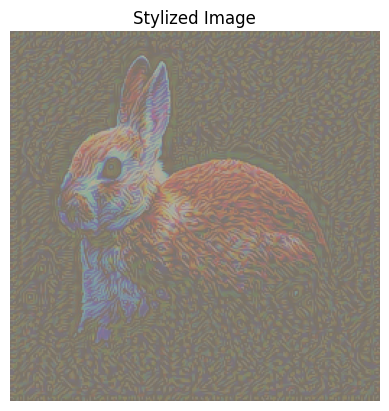

In [21]:
import torch
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load image with normalization
def load_image(path, size=256):
    image = Image.open(path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    image = transform(image).unsqueeze(0)
    return image.to(device)

# Load images
content = load_image("rabbit.jpg")
style = load_image("van_gogh.jpg")

# Load pretrained VGG19
vgg = models.vgg19(pretrained=True).features.to(device).eval()

# Gram matrix
def gram_matrix(tensor):
    b, c, h, w = tensor.size()
    tensor = tensor.view(c, h * w)
    return torch.mm(tensor, tensor.t())

# Feature extraction
def get_features(x):
    layers = {
        '0': 'conv1',
        '5': 'conv2',
        '10': 'conv3',
        '19': 'conv4',
        '28': 'conv5'
    }
    features = {}
    for name, layer in vgg._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
    return features

# Extract features (DETACHED to avoid graph error)
content_features = {k: v.detach() for k, v in get_features(content).items()}
style_features = {k: v.detach() for k, v in get_features(style).items()}

# Style gram matrices
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

# Target image
target = content.clone().requires_grad_(True).to(device)

# Optimizer
optimizer = optim.Adam([target], lr=0.003)

# Weights
content_weight = 1e4
style_weight = 1e2

# Training loop
for i in range(100):
    target_features = get_features(target)

    # Content loss
    content_loss = torch.mean(
        (target_features['conv4'] - content_features['conv4']) ** 2
    )

    # Style loss
    style_loss = 0
    for layer in style_grams:
        target_gram = gram_matrix(target_features[layer])
        style_gram = style_grams[layer]
        style_loss += torch.mean((target_gram - style_gram) ** 2)

    # Total loss
    total_loss = content_weight * content_loss + style_weight * style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    # Clamp values (stability)
    with torch.no_grad():
        target.clamp_(0, 1)

    if i % 50 == 0:
        print(f"Step {i}, Loss: {total_loss.item()}")

# Convert tensor to image (denormalize)
def im_convert(tensor):
    image = tensor.cpu().detach().clone()
    image = image.squeeze(0)
    image = image.permute(1, 2, 0)

    image = image * torch.tensor([0.229, 0.224, 0.225]) + \
            torch.tensor([0.485, 0.456, 0.406])

    image = image.clamp(0, 1)
    return image

# Show result
plt.imshow(im_convert(target))
plt.title("Stylized Image")
plt.axis("off")
plt.show()